# Parameter tuning for Duck

## Paths and settings

In [1]:
new_initial_state = False
new_tuning = True

In [2]:
path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
# path_to_data_folder = '/home/jovyan/data/98_paper2_kf_dtm/'

path_tc = path_to_data_folder + '01_tides/output/'
path_validation = path_to_data_folder + '02_Duck_validation_data/'

path_input_general = path_to_data_folder + '0_input_general/'
path_input = path_to_data_folder + '22_23_Duck_DEM/input/'
path_output = path_to_data_folder + '22_23_Duck_DEM/output/'
path_altimetry_output = path_to_data_folder + '21_Duck_altimetry/output/'
path_transect_polys = path_to_data_folder + '06_Duck_transect_polys/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2024_n36.6257_s35.7784_w-76.1201_e-75.3896.nc'
fn_ddtm = 'DeltaDTM_v1_0_N36W076.tif'

epsg = 4326 # WGS84
epsg_local = 32618

year_start = 1993
year_end = 2020 # included
num_years_per_bin = 1

import warnings
warnings.filterwarnings("ignore")

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import time
import itertools

from scipy import stats
from scipy.sparse import diags_array

from shapely import LineString

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colormaps as cm
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_visualisation

import P2_functions

In [4]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Static parameters

In [5]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Data

### Sea level

In [6]:
# Altimetry
fn = 'tp_plus_ales_epsg32618.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [7]:
# Tidal correction
fn = 'tides_duck.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

### Shorelines

In [8]:
# Cassie shorelines
folders = ['1_1992-08-10_1995-02-24/',
          '2_1995-03-21_2001-03-12/',
          '3_2001-04-13_2009-03-18/',
          '4_2009-04-12_2018-02-07/',
          '5_2018-02-23_2025-03-06/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

292 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 90 points (min: 55, max: 215).


#### Shoreline outlier rejection

In [9]:
med_sl = CD_geometry.median_shoreline_from_transect_intersections(c_shorelines, spacing=100, transect_length=5000, smooth_factor=10)
t_factor = 1 # threshold = t_factor * mean, (mean of distances to reference shoreline), points inside that range are kept
c_shorelines_corr = CD_geometry.shoreline_outlier_rejection(c_shorelines, med_sl, epsg, t_factor)
pickle.dump(c_shorelines_corr, open(path_output + 'c_shorelines_corr.pkl', 'wb'))

22.0% of shoreline points were discarded.


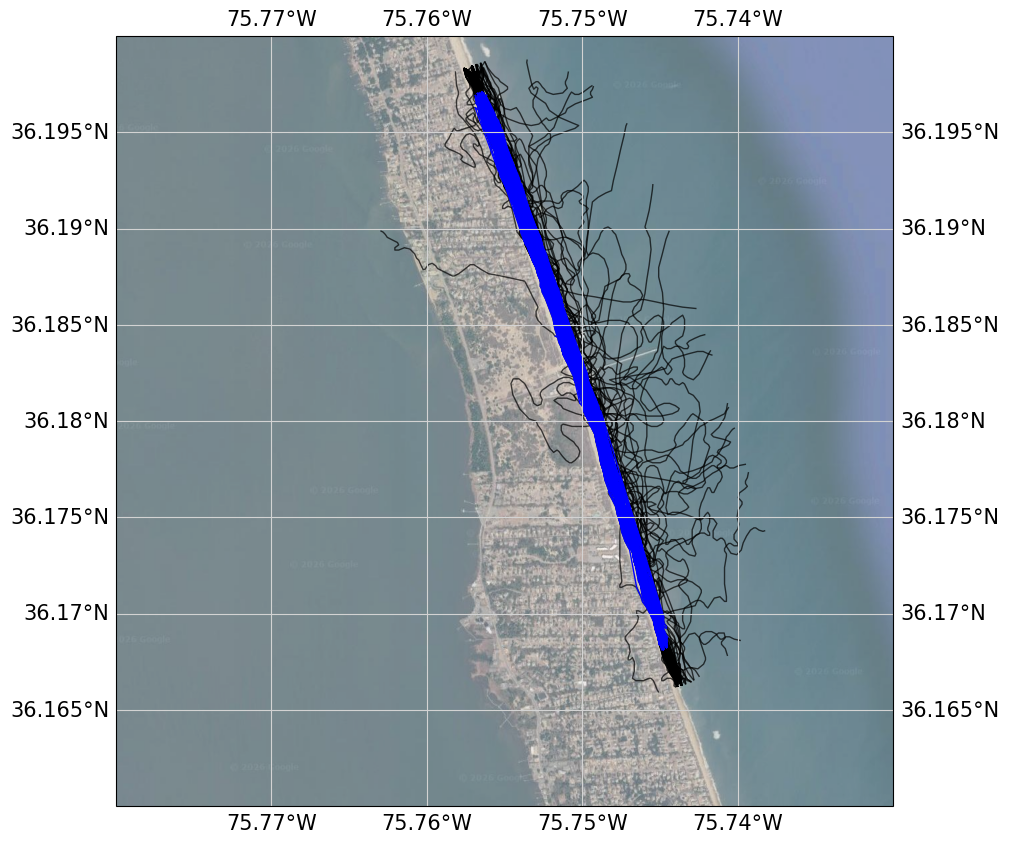

In [10]:
# Visual inspection of shoreline outlier rejection
projection = ccrs.PlateCarree()
extent = [-75.78, -75.73, 36.16, 36.2]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

# ax.add_geometries(poly_shorelines, crs=projection, facecolor='none', edgecolor='black')

for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='black', zorder=1, alpha=.7)
for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='blue', zorder=1, alpha=1)

### Validation data

In [11]:
duck_vali = xr.open_dataset(path_validation+'duck_validation.nc')

# Reduce to time period
vali_years = pd.to_datetime(duck_vali.time).year
idx_time, = np.where((vali_years >= year_start) & (vali_years <= year_end))
duck_vali = duck_vali.isel(time=idx_time)

# xarray DataSet to GeoDataFrame
lon_vali = duck_vali.longitude.values.reshape(-1)
lat_vali = duck_vali.latitude.values.reshape(-1)

elev_vali = duck_vali['elevation'].values.reshape(len(duck_vali.time), len(duck_vali.xFRF)*len(duck_vali.yFRF))

dates = pd.to_datetime(duck_vali.time)
vali_df = pd.DataFrame(elev_vali, index=dates)

# yearly means anchored in June
# https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
valid_df_yearly = vali_df.groupby(pd.Grouper(freq='YE-JUN')).mean()
valid_df_yearly.index = valid_df_yearly.index.year

vali_gdf = gpd.GeoDataFrame(valid_df_yearly.T, geometry=gpd.points_from_xy(lon_vali, lat_vali))
vali_gdf = vali_gdf.set_crs('4326')
vali_gdf.columns = [str(_) for _ in vali_gdf.columns]

vali_gdf = vali_gdf.drop(columns=['2012', '2021'], errors='ignore')
vali_gdf.to_file(path_output + 'duck_vali_gdf.geojson')

#### Map

#### Profiles

In [12]:
# Separate vali_gdf into profiles
profiles = {}

n_prof = 76 # number of points per profile

for profile in range(0,51):
    point_start = profile * n_prof
    point_end = profile * n_prof + n_prof
    profiles[str(profile)] = vali_gdf.loc[point_start:point_end]

#### Time series

### Transect polygons

In [13]:
transect_polys = pickle.load(open(path_transect_polys + 'transect_polys.pkl', 'rb'))

## Initial state

In [14]:
resolution = CD_geometry.dist_meter_to_dist_deg(50) # [deg], resolution of the target grid in x- and y-direction
fn_init = f'init_{epsg}_resolution_50m.tif'
if (not os.path.isfile(path_output + fn_init)) | new_initial_state:
    # Target area: polgon around the shorelines
    poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=resolution)
    pickle.dump(poly_sl_corr, open(path_output + f'poly_sl_corr{epsg}.pkl', 'wb'))

    # Initial state
    CD_kalman.initial_state(poly_sl_corr, med_sl, epsg, resolution, alt,
                            path_input+'2_global_DEMs/', path_output, fn_init, fn_gebco, fn_ddtm)
else:
    poly_sl_corr = pickle.load(open(path_output + f'poly_sl_corr{epsg}.pkl', 'rb'))

Always load `init`, even if it was computed in this go (otherwise there is one case where init is a dataframe, and one case where it is an xarray DataSet):

In [15]:
init = xr.open_dataset(path_output+fn_init).squeeze()

Text(0.5, 1.0, 'Initial state: GEBCO + DeltaDTM')

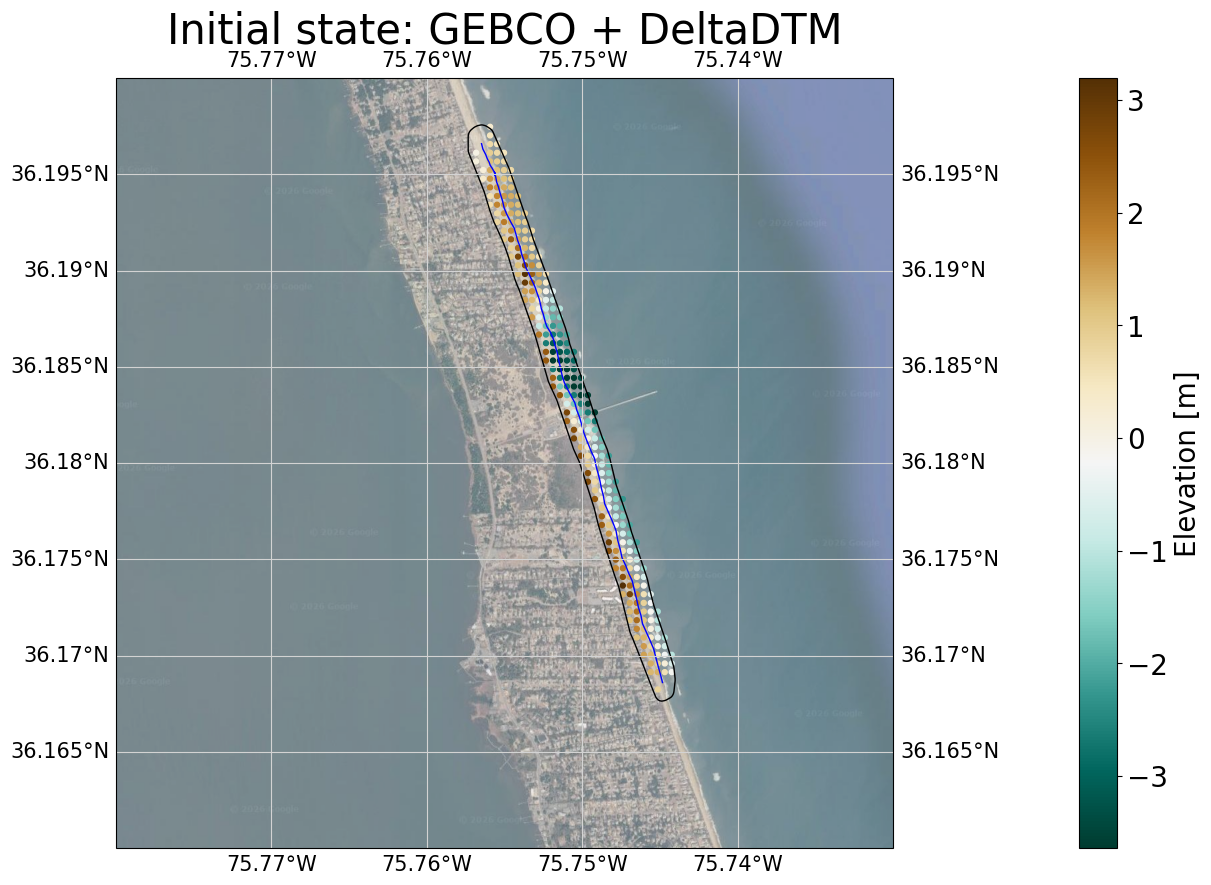

In [16]:
# Plot intial state
init_df = init.to_dataframe()
x = init_df.index.get_level_values('x')
y = init_df.index.get_level_values('y')

projection = ccrs.PlateCarree()
# extent = [-75.76, -75.735, 36.175, 36.19] # zoom in
extent = [-75.78, -75.73, 36.16, 36.2]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)
   
ax.add_geometries(poly_sl_corr, crs=projection, facecolor='none', edgecolor='black')
ax.add_geometries(med_sl, crs=projection, facecolor='none', edgecolor='blue')
    
plot = ax.scatter(x, y, c=init_df.band_data, transform=projection, marker='.', s=50,
                  cmap='BrBG_r') #, vmin=-10, vmax=10)
fig.colorbar(plot, shrink=1, pad=0.12, label='Elevation [m]')
ax.set_title('Initial state: GEBCO + DeltaDTM', fontsize=30)

# plt.savefig(f'{path_partun}initial_state.png', dpi=300, bbox_inches='tight')

## Tune

### Parameters

In [17]:
# sigma_l
# Minimum combined error
beach_slope_min = 0.001
rmse_h_cassie_min = 5
std_alt_min = 0.03
rms_eot20_min = 0.01 # from paper, table 3: 0.061
sigma_v_total_min = np.sqrt((beach_slope_min * rmse_h_cassie_min)**2 + std_alt_min**2 + rms_eot20_min**2)

# Maximum combined error
beach_slope_max = 0.02
rmse_h_cassie_max = 50
std_alt_max = .8
rms_eot20_max = 0.1
sigma_v_total_max = np.sqrt((beach_slope_max * rmse_h_cassie_max)**2 + std_alt_max**2 + rms_eot20_max**2)

print(f'Min: {round(sigma_v_total_min,2)} m, Max: {round(sigma_v_total_max,2)} m')

Min: 0.03 m, Max: 1.28 m


In [18]:
sigma_l_values =  np.linspace(sigma_v_total_min, sigma_v_total_max, 5) # [m]
factors = [1, 10, 25]
std_init_values = [1, 3, 9] # [m]

param_df = pd.DataFrame(list(itertools.product(factors, sigma_l_values, std_init_values)), columns=['factor', 'sigma_l', 'std_init'])

param_df['sigma_q'] = param_df['factor'] * param_df['sigma_l']
param_df

,factor,sigma_l,std_init,sigma_q
0,1,0.032016,1,0.032016
1,1,0.032016,3,0.032016
2,1,0.032016,9,0.032016
3,1,0.345143,1,0.345143
4,1,0.345143,3,0.345143
5,1,0.345143,9,0.345143
6,1,0.658269,1,0.658269
7,1,0.658269,3,0.658269
8,1,0.658269,9,0.658269
9,1,0.971396,1,0.971396


### Influence of beach slope

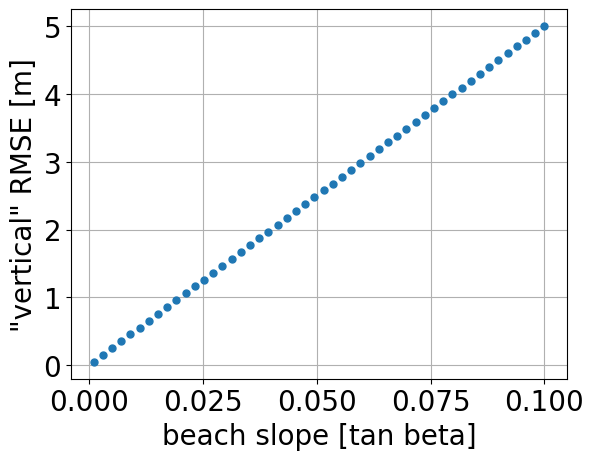

In [19]:
slopes = np.linspace(0.001, 0.1, 50)
vertical_variance = []
for slope in slopes:
    vertical_variance.append(slope * rmse_h_cassie_max)

fig, ax = plt.subplots()
ax.plot(slopes, vertical_variance, '.', ms=10)
ax.set_xlabel('beach slope [tan beta]')
ax.set_ylabel('"vertical" RMSE [m]')
ax.grid()

### Get beach slope from validation data

In [20]:
n = 1
# all_slopes = np.empty(0)
all_slopes = []

for prof_nr in profiles.keys():
    profile = profiles[prof_nr]
    # Reduce to area of the corrected shorelines
    profile_in_sl = profile[profile.intersects(poly_sl_corr)]
    
    for year in profile_in_sl.drop(columns='geometry').columns:
        x = profile_in_sl[year].index
        y = profile_in_sl[year].values
        slopes = CD_statistics.first_derivative(x, y, n)
        slopes_mean_over_one_profile = np.nanmean(slopes)
        all_slopes.append(slopes_mean_over_one_profile)
        # all_slopes = np.concatenate([all_slopes, slopes_mean_over_one_profile])

In [21]:
print('Beach slope statistics (all_slopes contains one average beach slope per profile and per year, so the mean of one measurement line)')
print(f'Mean beach slope: {np.nanmean(all_slopes)}')
print(f'Median beach slope: {np.nanmedian(all_slopes)}')
print(f'Minimum beach slope: {np.nanmin(np.abs(all_slopes))}')
print(f'Maximum beach slope: {np.nanmax(np.abs(all_slopes))}')

Beach slope statistics (all_slopes contains one average beach slope per profile and per year, so the mean of one measurement line)
Mean beach slope: -0.566849321699453
Median beach slope: -0.5987385271568944
Minimum beach slope: 0.27403061224489794
Maximum beach slope: 0.791608173076923


### Loop

In [23]:
if new_tuning:
    year_ref = 2006
    n_iter = 2

    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m]
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]
    
    # Store statistics for volume time series in DataFrames
    rmse_df = pd.DataFrame()
    corr_df = pd.DataFrame()
    pvalues_df = pd.DataFrame()
    trend_df = pd.DataFrame()
    errors_df = pd.DataFrame()

    for i in param_df.index:
        factor = param_df.loc[i, 'factor']
        sigma_q = param_df.loc[i, 'sigma_q']
        sigma_l = param_df.loc[i, 'sigma_l']
        std_init = param_df.loc[i, 'std_init']
        print(f'{i}: factor = {factor}, sigma_l = {sigma_l}, std_init = {std_init}')
        
        # Initialise state vector
        init_df = init.to_dataframe()
        x = init_df.index.get_level_values('x')
        y = init_df.index.get_level_values('y')    
        x_state = gpd.GeoDataFrame({'init': init_df.band_data.values}, geometry=gpd.points_from_xy(x, y))
        x_state = x_state.set_crs(epsg)

        # Covariance matrix of the initial state
        sigma_xx_init_df = gpd.GeoDataFrame({'sigma': std_init**2}, geometry=x_state.geometry, index=x_state.index)
        sigma_xx_init = diags_array(sigma_xx_init_df.sigma)

        # "Iteration 0"
        x_k = x_state['init'].copy()
        sigma_xx_k = sigma_xx_init

        # Initial trend 
        trends = gpd.GeoDataFrame({'trend_k':np.full(len(init_df.index), 0)}, geometry=x_state.geometry)

        for j in range(0, n_iter):
            x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(
          x_state, init, x_k, sigma_xx_k, year_start, year_end, num_years_per_bin, rs_shoreline,
          seg_length, alt, tidal_corr, epsg, epsg_local, T_is_identity, max_distance, w_id,
          max_noupdate, std_pseudobs, sigma_l, sigma_q, eps_factor, trends['trend_k'].copy(), year_ref)            

            # New trend
            trends[f'trend_{j}'] = CD_kalman.compute_trend_in_each_gridpoint(x_state)   
            # Overwrite  trend_k for next iteration
            trends['trend_k'] = trends[f'trend_{j}'].copy()

            # Overwrite x_k so that next iteration starts with residuals and not the full signal
            x_k = x_state.iloc[:,-1].copy() # last entry is x_up_2020 (or whatever end_year is specified)
            sigma_xx_k = sigma_xx_up[list(sigma_xx_up)[-1]] # unordered dict, but should also access end_year

        x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, T, eps_factor)

        # Re-add trend
        x_state_readd = x_state.copy()
        x_state_s_readd = x_state_s.copy()

        all_trends = trends.drop(columns=['geometry', 'trend_k']+[col for col in trends.columns if col.startswith('mean_')])
        trend_sum = all_trends.cumsum(axis=1).iloc[:,-2] # second last column, because last trend was not subtracted

        year_list = [int(col.split('_')[-1]) for col in x_state.columns if col.startswith('x_up_')]
        for year in year_list:
            deltaYear = year - year_ref
            x_state_readd[f'x_up_{year}'] += trend_sum * deltaYear
            x_state_readd[f'x_pred_{year}'] += trend_sum * deltaYear
            x_state_s_readd[f'x_s_{year}'] += trend_sum * deltaYear

        kf_interp, rts_interp = CD_kalman.interpolate_results(vali_gdf, x_state_readd, x_state_s_readd)

        # Volume change time series
        volumes_vali, volumes_kf, volumes_rts = P2_functions.get_all_volumes(vali_gdf, kf_interp, rts_interp, transect_polys, epsg_local)
        trends, corr, pvalues, rmse = P2_functions.volume_stats_Duck(volumes_vali, volumes_kf, volumes_rts, print_output=False)
        
        rmse_df[i] = pd.DataFrame([rmse]).T[0]
        corr_df[i] = pd.DataFrame([corr]).T[0]
        pvalues_df[i] = pd.DataFrame([pvalues]).T[0]
        trend_df[i] = pd.DataFrame([trends]).T[0]

    rmse_df.to_pickle(path_output+'partun_volumes_rmse.pkl')
    corr_df.to_pickle(path_output+'partun_volumes_corr.pkl')
    pvalues_df.to_pickle(path_output+'partun_volumes_pvalues.pkl')
    trend_df.to_pickle(path_output+'partun_volumes_trends.pkl')
        
else:
    rmse_df = pd.read_pickle(path_output+'partun_volumes_rmse.pkl')
    corr_df = pd.read_pickle(path_output+'partun_volumes_corr.pkl')
    pvalues_df = pd.read_pickle(path_output+'partun_volumes_pvalues.pkl')
    trend_df = pd.read_pickle(path_output+'partun_volumes_trends.pkl')
    print("Loaded files.")

0: factor = 1, sigma_l = 0.032015621187164243, std_init = 1
Forward run done. Needed  7.7 seconds.
Forward run done. Needed  7.4 seconds.
Backward run done. Needed  0.5 seconds.
Interpolation done. Needed  1.3 seconds.
1: factor = 1, sigma_l = 0.032015621187164243, std_init = 3


KeyboardInterrupt: 

## Plots

In [ ]:
cmap = cm['Blues_r']
c_list = cmap(np.linspace(0,.6,3))
# c_list = ['purple', 'darkblue', 'limegreen'] # encode sigma_q (factors of sigma_l) with colour
ls_list = ['-', '-.', ':'] # encode sigma_gebco with linestyle

In [ ]:
def plot_legend(ax, c_list, ls_list, factors, std_init_values):
    legend_elements = [
        Line2D([0], [0], color='none', label='$\\bf{Color: \\sigma_q}$', lw=0, ms=0),  # Subtitle
        
        Line2D([0], [0], color=c_list[0], label=f'$\\sigma_{{q}}$ = {factors[0]}$\\cdot \\sigma_{{obs}}$ m'),
        Line2D([0], [0], color=c_list[1], label=f'$\\sigma_{{q}}$ = {factors[1]}$\\cdot \\sigma_{{obs}}$ m'),
        Line2D([0], [0], color=c_list[2], label=f'$\\sigma_{{q}}$ = {factors[2]}$\\cdot \\sigma_{{obs}}$ m'),

        Line2D([0], [0], color='none', label='', lw=0, ms=0), # dummy for white space
        Line2D([0], [0], color='none', label='$\\bf{Linestyle: \\sigma_{{init}}}$', lw=0, ms=0),  # Subtitle

        Line2D([0], [0], color='grey', ls=ls_list[0], label=f'$\\sigma_{{init}}$ = {std_init_values[0]} m'),
        Line2D([0], [0], color='grey', ls=ls_list[1], label=f'$\\sigma_{{init}}$ = {std_init_values[1]} m'),
        Line2D([0], [0], color='grey', ls=ls_list[2], label=f'$\\sigma_{{init}}$ = {std_init_values[2]} m'),

        Line2D([0], [0], color='none', label='', lw=0, ms=0), # dummy for white space

        # Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(2.95,1))

### Volume changes

In [ ]:
def plot_vol_stats(ax, data, area, ylabel, title, corr=False, plot_zero=False, ylim=None):
    for f, factor in enumerate(factors):
        for g, std_init in enumerate(std_init_values):
            idx, = np.where((param_df.factor == factor) & (param_df.std_init == std_init))
            ax.plot(param_df.loc[idx, 'sigma_l'], data[idx], ls=ls_list[g], c=c_list[f], marker='.')
            
            if corr:
                pvalues_box = np.where(pvalues_df.T.loc[idx, area] < 0.05)[0]
                ax.plot(param_df.loc[idx[pvalues_box], 'sigma_l'], corr_df.loc[area,idx[pvalues_box]].values,
                        marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
                ax.legend(handles=[Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')], loc='lower right')

            if plot_zero:
                ax.axhline(y=0, color='grey')            

    if ylim != None:
        ax.set_ylim(ylim[0], ylim[1])

    # if not corr:
    #     ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        # ax.ticklabel_format(useOffset=False, style='plain')
    
    ax.set_xlabel(r'$\sigma_{l}$ [m]')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=22)
    ax.grid()

In [ ]:
def mark_selected_param(ax, idx_selected, data):
    params_selected = param_df.iloc[idx_selected]
    ax.plot(params_selected['sigma_l'], data.iloc[idx_selected], 'o', c='None', markeredgecolor='red', ms=10, markeredgewidth=2)

#### Remove height difference between validation and new DTM
with bias from notebook 23

In [ ]:
bias = pickle.load(open(path_output + 'bias.pkl', 'rb'))
vali_red = vali_gdf.copy()
vali_red.loc[:, vali_red.columns != 'geometry'] += bias

#### Percentages

In [ ]:
trend_diff = pd.DataFrame()
trend_diff['all'] = trend_df.T['rts'] - trend_df.T['vali']

vol_vali = pd.DataFrame()
vol_vali['duck'] = CD_geometry.compute_volume_changes(vali_red, poly_target_red, col_name='', epsg_out=32618)

x = vol_vali.index.values.astype(int)
trend_vali, _, _ = CD_statistics.compute_trend_with_error(x, vol_vali['duck'])

trend_diff_perc = pd.DataFrame(columns=['duck'], index=param_df.index)
# Find the parameter combinations where both trends have the same sign
idx_pos, = np.where(np.sign(trend_df.T['rts']) == np.sign(trend_df.T['vali']))
idx_neg, = np.where(np.sign(trend_df.T['rts']) != np.sign(trend_df.T['vali']))

# Same sign: Quotient of absolute trends
trend_diff_perc.loc[idx_pos, 'duck'] = (np.abs(trend_diff.loc[idx_pos, 'all']) / np.abs(trend_vali)) * 100
# Different sign: Trend diff perc should end up with negative sign
trend_diff_perc.loc[idx_neg, 'duck'] = (trend_diff.loc[idx_neg, 'all'] / trend_vali) * 100

rmse_perc = (rmse_df.T[0]/np.abs(np.mean(vol_vali['duck']))) * 100

In [ ]:
# idx_selected = 18 # index of the parameters selected for validation
# idx_selected = 4
idx_selected = 19

fig, axs = plt.subplots(1,3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.3, wspace=.28)

# Absolute trend differences
# plot_vol_stats(axs[0], trend_diff['all'], area=0, ylabel=r'[m$^3$/year]', title='Trend difference', plot_zero=True)

# Relative trend differences (% of total volume trend from validation data)
plot_vol_stats(axs[0], trend_diff_perc['duck'], area=0, ylabel='% of total volume trend', title='Trend difference', plot_zero=False)
mark_selected_param(axs[0], idx_selected, trend_diff_perc['duck'])

# Absolute RMSE
# plot_vol_stats(axs[1], rmse_df.T[0], area=0, ylabel=r'[m$^3$]', title='RMSE')
# mark_selected_param(axs[1], idx_selected, rmse_df.T[0])
# axs[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

# Relative RMSE (% of the mean of the total volume)
plot_vol_stats(axs[1], rmse_perc, area=0, ylabel='% of mean total volume', title='RMSE')
mark_selected_param(axs[1], idx_selected, rmse_perc)

ylim_corr = [-1,1]
plot_vol_stats(axs[2], corr_df.T[0], area=0, ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
mark_selected_param(axs[2], idx_selected, corr_df.T)

plot_legend(axs[1], c_list, ls_list, factors, std_init_values)
fig.suptitle('Duck', y=1.13, fontsize=25);

plt.savefig(f'{path_output}Duck_partun_volume_change_stats.png', dpi=300, bbox_inches='tight')